In [1]:
import os
import re
import time
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import ContextualCompressionRetriever, EnsembleRetriever
from langchain_classic.retrievers.document_compressors import LLMChainExtractor
from dotenv import load_dotenv

load_dotenv()

MODEL = "gpt-4o-mini"
llm = ChatOpenAI(model=MODEL)
embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")


In [2]:
documents = [
    Document(page_content="트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.", metadata={"id": "d1"}),
    Document(page_content="BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.", metadata={"id": "d2"}),
    Document(page_content="GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.", metadata={"id": "d3"}),
    Document(page_content="RAG는 검색 증강 생성 기법으로 외부 지식을 LLM에 결합하여 할루시네이션을 줄입니다.", metadata={"id": "d4"}),
    Document(page_content="벡터 데이터베이스는 임베딩 벡터를 저장하고 유사도 기반 검색을 수행합니다. FAISS, Pinecone 등이 있습니다.", metadata={"id": "d5"}),
    Document(page_content="파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.", metadata={"id": "d6"}),
    Document(page_content="프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.", metadata={"id": "d7"}),
    Document(page_content="토큰화는 텍스트를 모델이 처리할 수 있는 단위로 분할하는 과정입니다. BPE, WordPiece 등이 사용됩니다.", metadata={"id": "d8"}),
]


In [3]:
vectorstore = FAISS.from_documents(documents, embeddings_model)
bm25_retriever = BM25Retriever.from_documents(documents, k=5)

In [4]:
doc_embeddings = {}

def get_embedding(text):
    return np.array(embeddings_model.embed_query(text))

for doc in doc_embeddings:
    doc_embeddings[doc.metadata['id']] = get_embedding(doc.page_content)

In [5]:
# query - doc1, doc2, ...   Cross-encoder
# 사용자 쿼리 : 트랜스포머와 BERT의 관계?
#     1) 트랜스포머는 ~~~~
    
#     2) BERT는 ~~~ 입니다

In [6]:
# query -> emb_query
# doc1 -> emb_doc1
# ..
# => 문장들간의 의미적 관련성

In [7]:
# 검색 -> doc1, doc2, ... doc5 -> 후보문서 -> re-rank ----(Cross-encoder / llm)--> re-ranked -> generate

In [8]:
# Cross-encoder
# 1. normal vector retriever
# query ---(emb_model)---> query_emb
# doc1 ----(emb_model) ---> doc1_emb

# # 2. cross-encoder retriever
# (query - doc1 ) ---(emb_model)---> (query_doc1_emb)
# (query - doc2 ) ---(emb_model)---> (query_doc2_emb)

# LLM
# query, doc1 --(LLM)---> score, t/f

In [9]:
def vector_search(query, vectorstore, top_k=5):
    results = vectorstore.similarity_search_with_score(query, k=top_k)
    return [(doc, 1.0 / (1.0 + score)) for doc, score in results]

query = "트랜스포머와 BERT의 관계"
results = vector_search(query, vectorstore)
results

[(Document(id='eb2cb63d-1885-48c2-9b92-6195fd8739ad', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  np.float32(0.52375495)),
 (Document(id='465aa887-ef0f-473a-a4f1-87c0f6200a9b', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  np.float32(0.46395132)),
 (Document(id='12dafb0d-8c4e-4437-8941-b71d5d55b5ba', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  np.float32(0.41890207)),
 (Document(id='706bb840-ee88-4b02-9a04-80d1f22277ec', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  np.float32(0.41281974)),
 (Document(id='0b744e36-8bef-4803-99dd-f99ae38d51bd', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  np.float32(0.39723063))]

In [10]:
def keyword_rerank(query, search_results):
    query_terms = set(query.lower().split())
    reranked = []
    
    for doc, orig_score in search_results:
        doc_terms = doc.page_content.lower().split()
        keyword_hits = sum(1 for t in doc_terms if t in query_terms)   # [1, 1]
        new_score = orig_score + 0.1 * keyword_hits
        reranked.append((doc, new_score, orig_score))
        
    reranked.sort(key = lambda x: x[1], reverse=True)
    return reranked

In [11]:
reranked = keyword_rerank(query, results)
reranked

[(Document(id='eb2cb63d-1885-48c2-9b92-6195fd8739ad', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  np.float32(0.52375495),
  np.float32(0.52375495)),
 (Document(id='465aa887-ef0f-473a-a4f1-87c0f6200a9b', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  np.float32(0.46395132),
  np.float32(0.46395132)),
 (Document(id='12dafb0d-8c4e-4437-8941-b71d5d55b5ba', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  np.float32(0.41890207),
  np.float32(0.41890207)),
 (Document(id='706bb840-ee88-4b02-9a04-80d1f22277ec', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  np.float32(0.41281974),
  np.float32(0.41281974)),
 (Document(id='0b744e36-8bef-4803-99dd-f99ae38d51bd', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  np.float32(0.39723063),
  np.float32(0.397

In [12]:
def rank_change(original_results, reranked_results):
    
    orig_ranks = {doc_.metadata['id']: i+1 for i, (doc_, _) in enumerate(original_results)}
    new_ranks = {doc_.metadata['id']: i+1 for i, (doc_, _, _) in enumerate(reranked_results)}
    
    changes = []
    for doc_id in orig_ranks:
        old_r = orig_ranks[doc_id]
        new_r = new_ranks.get(doc_id, -1)
        
        changes.append({
            'doc_id' : doc_id,
            'before' : old_r,
            'after' : new_r,
            'change' : old_r - new_r
        })
        
    return pd.DataFrame(changes).sort_values('after')


In [13]:
df = rank_change(results, reranked)
df

,doc_id,before,after,change
0,d1,1,1,0
1,d2,2,2,0
2,d3,3,3,0
3,d6,4,4,0
4,d7,5,5,0


In [14]:
# ranked -> (Cross-encoder / LLM) -> reranked

In [15]:
# vector search : 쿼리 / 문서 : Bi-encoder

In [16]:
# BM25 -> rerank 
# (쿼리 - 문서) -> rerank
# LLM -> rerank

In [17]:
# TF-IDF 
class BM25Reranker: 
    def __init__(self, k1 = 1.5, b=0.75):
        self.k1 = k1
        self.b = b
    
    def rerank(self, query, search_results):
        docs = [doc for doc, _ in search_results]
        tokenized = [doc.page_content.lower().split() for doc in docs]
        
        avg_dl = np.mean([len(t) for t in tokenized])
        
        df_count = Counter()
        for tokens in tokenized:
            for t in set(tokens):
                df_count[t] += 1
        N = len(docs)
        
        query_tokens = query.lower().split()
        scored = []
        
        for i, doc in enumerate(docs):
            score = 0.0
            doc_len = len(tokenized[i])
            tf_count = Counter(tokenized[i])
            
            for qt in query_tokens :
                tf = tf_count.get(qt, 0)
                if tf == 0:
                    continue
                
                df = df_count.get(qt, 0)
                idf = math.log((N-df + 0.5) / (df + 0.5) + 1)    # tf-idf : tf x idf   10 -> log(10) : 1 (0.1 -> (-1))
                numerator = tf * (self.k1 + 1)
                denominator = tf + self.k1 * (1 - self.b + self.b * doc_len /avg_dl)
                score +=  idf * numerator / denominator
        
            scored.append((doc, score))
        
        scored.sort(key = lambda x: x[1], reverse=True)
        return scored
                
        
        

In [18]:
bm25_reranker = BM25Reranker()
bm25_results = bm25_reranker.rerank(query, results)

In [19]:
bm25_results

[(Document(id='eb2cb63d-1885-48c2-9b92-6195fd8739ad', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  0.0),
 (Document(id='465aa887-ef0f-473a-a4f1-87c0f6200a9b', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  0.0),
 (Document(id='12dafb0d-8c4e-4437-8941-b71d5d55b5ba', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  0.0),
 (Document(id='706bb840-ee88-4b02-9a04-80d1f22277ec', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  0.0),
 (Document(id='0b744e36-8bef-4803-99dd-f99ae38d51bd', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  0.0)]

In [20]:
# ['d1'] 프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.
# ['d2'] 프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.

In [21]:
def llm_rerank(query, search_results, top_k=3):
    docs_text = '\n'.join(
        f"[{doc.metadata['id']}] {doc.page_content}" for doc, _ in search_results
    )
    
    score_template = ", ".join(f'"{doc.metadata["id"]}": 0.0-1.0' for doc, _ in search_results)
    
    scoring_chain = ChatPromptTemplate.from_messages([
        ('system', '당신은 scoring 시스템 입니다. 항상 json 형태로 출력하세요'),
        ('human', """다음 쿼리에 대해 각 문서의 관련성을 0.0~1.0으로 평가하세요.
        
        쿼리 : {query}
        
        문서들 :
        {docs_text}
        
        "스트링으로 묶지말고" JSON으로 답하세요:
        {{"scores" : {{{score_template}}}}}""")
    ]) | llm | StrOutputParser()
    
    result = scoring_chain.invoke({
        'query' : query,
        'docs_text' : docs_text,
        'score_template' : score_template
    })
    
    cleaned = result.strip()
    if cleaned.startswith('```json'):
        cleaned = cleaned.replace('```json', '')
        cleaned = cleaned.replace('```', '')
        
    parsed = json.loads(cleaned)
    scores = parsed.get('scores', {})
    
    scored = []
    
    for doc, orig in search_results:
        rerank_score = scores.get(doc.metadata['id'],0.0)
        scored.append((doc, float(rerank_score), orig))
        
    scored.sort(key = lambda x : x[1], reverse=True)
    return scored[:top_k]

In [22]:
query # BERT : 

'트랜스포머와 BERT의 관계'

In [23]:
results

[(Document(id='eb2cb63d-1885-48c2-9b92-6195fd8739ad', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  np.float32(0.52375495)),
 (Document(id='465aa887-ef0f-473a-a4f1-87c0f6200a9b', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  np.float32(0.46395132)),
 (Document(id='12dafb0d-8c4e-4437-8941-b71d5d55b5ba', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  np.float32(0.41890207)),
 (Document(id='706bb840-ee88-4b02-9a04-80d1f22277ec', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  np.float32(0.41281974)),
 (Document(id='0b744e36-8bef-4803-99dd-f99ae38d51bd', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  np.float32(0.39723063))]

In [24]:
llm_results = llm_rerank(query, results, top_k=3)

In [25]:
llm_results

[(Document(id='465aa887-ef0f-473a-a4f1-87c0f6200a9b', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  1.0,
  np.float32(0.46395132)),
 (Document(id='12dafb0d-8c4e-4437-8941-b71d5d55b5ba', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  0.4,
  np.float32(0.41890207)),
 (Document(id='eb2cb63d-1885-48c2-9b92-6195fd8739ad', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  0.3,
  np.float32(0.52375495))]

In [26]:
def hybrid_rerank(query, search_results, bm25_weight = 0.3):
    bm25 = BM25Reranker()
    bm25_scored = bm25.rerank(query, search_results)
    bm25_map = {doc.metadata['id'] : score for doc, score in bm25_scored}
    
    llm_scored = llm_rerank(query, search_results, top_k = len(search_results))
    llm_map = {doc.metadata['id'] : score for doc, score, _ in llm_scored}
    
    def normalize(scores_dict):
        vals = list(scores_dict.values())
        min_, max_ = min(vals), max(vals)
        range_ = max_ - min_ if max_ > min_ else 1e-8
        return {k : (v - min_) / range_ for k, v in scores_dict.items()}
    
    bm25_norm = normalize(bm25_map)
    llm_norm = normalize(llm_map)
    
    combined = []
    for doc, _ in search_results:
        did = doc.metadata['id']
        score = bm25_weight * bm25_norm.get(did, 0) + (1- bm25_weight) * llm_norm.get(did, 0)
        
        combined.append((doc, score))
    combined.sort(key = lambda x:x[1], reverse=True)
    return combined

In [27]:
hybrid = hybrid_rerank(query, results)

In [28]:
hybrid

[(Document(id='465aa887-ef0f-473a-a4f1-87c0f6200a9b', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  0.7),
 (Document(id='12dafb0d-8c4e-4437-8941-b71d5d55b5ba', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  0.35),
 (Document(id='eb2cb63d-1885-48c2-9b92-6195fd8739ad', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  0.17499999999999996),
 (Document(id='706bb840-ee88-4b02-9a04-80d1f22277ec', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  0.0),
 (Document(id='0b744e36-8bef-4803-99dd-f99ae38d51bd', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  0.0)]

In [29]:
# pointwise reranking (1개씩 넣는다)
# - 정확, 이유를 명확하게 설명, 빠르다(병렬)
# - 비용, 문서간 비교를 못한다
# listwise reranking  (N개씩 넣는다 : 이 문서들을 정렬해줘, 스코어링해줘) 
# - 비용, 문서간 비교를 한다
# - 할루시네이션/불명확한 설명, 컨텍스트(많은 문서)

In [30]:
# 5개 -> listwise
# 빠른 응답이 필요한 경우 -> 1개씩

In [31]:
# RAG - Retriever (Reranker) -> generator
# threshold scoring : 0.5 이하는 올리지마  : fixed threshold

# dynamic threshold : mean - 1 * sigma (표준편차) : quantitle
# scoring gap : 점수차
# top_k : 

In [32]:
def llm_listwise_rerank(query, search_results):
    docs_text = '\n'.join(
            f"{i+1}. [{doc.metadata['id']}] {doc.page_content[:80]}" for i, (doc, _) in enumerate(search_results)
    )
    
    ranking_chain = ChatPromptTemplate.from_messages([
        ('system', "당신은 문서 랭킹 시스템입니다"),
        ('human', """다음 문서들을 쿼리와의 관련성 순서로 정렬하세요.
        
        쿼리 : {query}
        
        문서들 : {docs_text}
        
        가장 관련성 높은 순서대로 문서 번호를 쉼표로 나열하세요 (예: 3,1,5,2,4):""")
    ]) | llm | StrOutputParser()
    
    result = ranking_chain.invoke({'query' : query, 'docs_text' : docs_text})
    
    order = [int(x.strip()) for x in result.strip().split(',')]
    
    docs_list = [doc for doc, _ in search_results]
    reranked = []
    for rank, idx in enumerate(order):
        if 1<=idx<=len(docs_list):
            docs = docs_list[idx-1]
            reranked.append((docs, 1.0-rank*0.1))
            
    return reranked

In [33]:
listwise = llm_listwise_rerank(query, results)

In [34]:
listwise

[(Document(id='465aa887-ef0f-473a-a4f1-87c0f6200a9b', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  1.0),
 (Document(id='eb2cb63d-1885-48c2-9b92-6195fd8739ad', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  0.9),
 (Document(id='12dafb0d-8c4e-4437-8941-b71d5d55b5ba', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  0.8),
 (Document(id='706bb840-ee88-4b02-9a04-80d1f22277ec', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  0.7),
 (Document(id='0b744e36-8bef-4803-99dd-f99ae38d51bd', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  0.6)]

In [35]:
class ScoreFilter:
    
    @staticmethod
    def fixed_threshold(scored_docs, threshold= 0.5):
        return [(doc, s) for doc, s in scored_docs if s >= threshold]
    
    @staticmethod
    def dynamic_threshold(scored_docs, std_factor) : 
        scores = [s for _, s in scored_docs]
        threshold = np.mean(scores) - std_factor * np.std(scores)
        return [(doc, s) for doc, s in scored_docs if s >= threshold]
    
    @staticmethod
    def score_gap(scored_docs, min_docs=2):
        if len(scored_docs) <= min_docs:
            return scored_docs
        
        scores = [s for _, s in scored_docs]
        gaps = [(scores[i] - scores[i+1], i+1) for i in range(len(scores)-1)]
        max_gap_idx = max(gaps, key=lambda x:x[0])[1]
        cut = max(min_docs, max_gap_idx)
        return scored_docs[:cut]



In [36]:
# sf = ScoreFilter()
# sf.abc()

In [37]:
test_scores = [(Document(page_content="", metadata = {'id': f'd{i}'}), s) for i, s in enumerate([0.9, 0.85, 0.7, 0.5, 0.2])]
test_scores

[(Document(metadata={'id': 'd0'}, page_content=''), 0.9),
 (Document(metadata={'id': 'd1'}, page_content=''), 0.85),
 (Document(metadata={'id': 'd2'}, page_content=''), 0.7),
 (Document(metadata={'id': 'd3'}, page_content=''), 0.5),
 (Document(metadata={'id': 'd4'}, page_content=''), 0.2)]

In [38]:
filtered = ScoreFilter.fixed_threshold(test_scores, threshold= 0.5)

In [39]:
filtered

[(Document(metadata={'id': 'd0'}, page_content=''), 0.9),
 (Document(metadata={'id': 'd1'}, page_content=''), 0.85),
 (Document(metadata={'id': 'd2'}, page_content=''), 0.7),
 (Document(metadata={'id': 'd3'}, page_content=''), 0.5)]

In [40]:
filtered = ScoreFilter.dynamic_threshold(test_scores, std_factor=1)
filtered

[(Document(metadata={'id': 'd0'}, page_content=''), 0.9),
 (Document(metadata={'id': 'd1'}, page_content=''), 0.85),
 (Document(metadata={'id': 'd2'}, page_content=''), 0.7),
 (Document(metadata={'id': 'd3'}, page_content=''), 0.5)]

In [41]:
filtered = ScoreFilter.score_gap(test_scores, min_docs=2)
filtered

[(Document(metadata={'id': 'd0'}, page_content=''), 0.9),
 (Document(metadata={'id': 'd1'}, page_content=''), 0.85),
 (Document(metadata={'id': 'd2'}, page_content=''), 0.7),
 (Document(metadata={'id': 'd3'}, page_content=''), 0.5)]

In [42]:
class AdaptiveFilter:
    
    # 점수의 분포에 따라서 score filtering 전략을 자동으로 선택
    
    @staticmethod # decorator
    def adapt_filter(scored_docs):
        scores = [s for _, s in scored_docs]
        std = np.std(scores)
        score_range = max(scores) - min(scores)
        
        if std > 0.2:
            result = ScoreFilter.score_gap(test_scores, min_docs=2)
        elif score_range < 0.1:
            result = scored_docs[:len(scored_docs)//2]
        else:
            result = ScoreFilter.dynamic_threshold(test_scores, std_factor=1)
        
        return result
    

In [43]:
filtered = AdaptiveFilter.adapt_filter(test_scores)
filtered

[(Document(metadata={'id': 'd0'}, page_content=''), 0.9),
 (Document(metadata={'id': 'd1'}, page_content=''), 0.85),
 (Document(metadata={'id': 'd2'}, page_content=''), 0.7),
 (Document(metadata={'id': 'd3'}, page_content=''), 0.5)]

In [44]:
# Context compression
# gpt-4o mini : 128K 토큰 (system prompt, (context1, context2 ...), user_prompt, 답변을 위한 공간)
# 하네스 엔지니어링 : compress 전략  100k -> 압축해라, 턴이 20턴정도 끝나면 압축해라 ...

In [45]:
# 에이전트 -> 잘하고 내가 편하다 -> 위험해짐 
#             정보를 감출수록 -> 불편해짐

In [46]:
# mmr : retriever : Embedding, Bm25, Hybrid, Maximum Marginal Relevance

In [47]:
# 쿼리 : 하네스 엔지니어링
# -> 쿼리랑 가장 유사한 문서들을 찾아옵니다.

In [48]:
# 1. 하네스 엔지니어링은 ~~~입니다.
# 2. ~~~
# 3. ~~~

# Relevance <-----> Diversity (다양성)

In [49]:
# P = 0.1, 0.2, ..
# mmr = P * Relevance(s, query) - (1-P)* max(Similarity(s, selected))

In [50]:
# retrieved = [1, 2, 3, 4, 5]
# selected = [1]
# K 

In [51]:
[(Document(id='f941a5a5-8291-41c4-97c4-8719bedacde4', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  1.0),
 (Document(id='0820d82b-7f85-4f20-9278-df128485b595', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  0.9),
 (Document(id='9711ac83-c999-43eb-8556-3dd19c3ec446', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  0.8),
 (Document(id='08c38071-9fc0-463a-a01b-5651b4231e2b', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  0.7),
 (Document(id='a81e6fa7-5295-4594-a085-23867b311ae3', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  0.6)]


[(Document(id='f941a5a5-8291-41c4-97c4-8719bedacde4', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  1.0),
 (Document(id='0820d82b-7f85-4f20-9278-df128485b595', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  0.9),
 (Document(id='9711ac83-c999-43eb-8556-3dd19c3ec446', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  0.8),
 (Document(id='08c38071-9fc0-463a-a01b-5651b4231e2b', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  0.7),
 (Document(id='a81e6fa7-5295-4594-a085-23867b311ae3', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  0.6)]

In [52]:
import re
def extractive_compress(query, document, max_sentences=3):
#     sentences = document.split('.')
    sentences = re.split(r'[.!?]\s*', document)
    
    if not sentences:
        return document
    
    query_terms = set(query.lower().split())
    
    scored = []
    for sent in sentences:
        sent_terms = set(sent.lower().split())
        overlap = len(query_terms & sent_terms)
        scored.append((sent, overlap))
        
    scored.sort(key = lambda x: x[1], reverse=True)
    selected = [s for s, _ in scored[:max_sentences]]
    
    return ". ".join(selected) + "."

In [53]:
long_doc = "트랜스포머는 2017년 구글이 발표한 아키텍처입니다. Self-Attention 메커니즘이 핵심입니다. 이전의 RNN, LSTM과 달리 병렬 처리가 가능합니다. BERT와 GPT 모두 트랜스포머를 기반으로 합니다. 자연어 처리뿐 아니라 컴퓨터 비전에서도 활용됩니다"
query = "트랜스포머와 BERT의 관계"
compressed = extractive_compress(query, long_doc, max_sentences=3)
compressed

'트랜스포머는 2017년 구글이 발표한 아키텍처입니다. Self-Attention 메커니즘이 핵심입니다. 이전의 RNN, LSTM과 달리 병렬 처리가 가능합니다.'

In [54]:
compress_chain = ChatPromptTemplate.from_messages([
    ("system", "당신은 문서 요약 전문가입니다"),
    ("human", """다음 문서에서 쿼리에 답하는데 필요한 핵심 정보만 추출하세요.
    불필요한 내용은 제거하고, {max_tokens}자 이내로 압축하세요.
    
    쿼리 : {query}
    문서 : {document}
    
    압축결과:""")
]) | llm | StrOutputParser()

In [55]:
def llm_compress(query, document, max_tokens=100):
    return compress_chain.invoke({
        'query' : query,
        'document' : document,
        'max_tokens' : max_tokens
    })

In [56]:
compressed_llm = llm_compress(query, long_doc)

In [57]:
compressed_llm

'트랜스포머는 2017년 구글이 발표한 아키텍처로, BERT와 GPT의 기반입니다.'

In [58]:
compressor = LLMChainExtractor.from_llm(llm)
compressor_retriever = ContextualCompressionRetriever(base_compressor = compressor, 
                                                      base_retriever=vectorstore.as_retriever(search_kwargs={'k':3}))

In [59]:
compressed_docs = compressor_retriever.invoke(query)

In [60]:
compressed_docs

[Document(metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
 Document(metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.')]

In [61]:
# 압축 품질 평가 : 압축률(200자 -> 100자), 키워드 보존율, 의미 보존도 (emb)
def evaluate_compression(original, compressed, query):
    # 1) 압축율
    ratio = len(compressed)  / len(original)
    
    # 2) 키워드 보존율
    query_terms = set(query.lower().split())
    orig_terms = set(original.lower().split())
    comp_terms = set(compressed.lower().split())
    
    orig_query_terms = query_terms & orig_terms
    comp_query_terms = query_terms & comp_terms
    keyword_coverage = len(comp_query_terms) / len(orig_query_terms) if orig_query_terms else 1.0
    
    # 3) 의미 보존도
    original_emb = np.array(embeddings_model.embed_query(original))  # get_embedding(original)
    compressed_emb = get_embedding(compressed)
    
    semantic_similarity = np.dot(original_emb, compressed_emb) / (np.linalg.norm(original_emb) * np.linalg.norm(compressed_emb))
    
    return {
        'compression_ratio' : ratio,
        'keyword_coverage' : keyword_coverage,
        'semantic_similarity' : semantic_similarity
    }

In [62]:
evaluate_compression(long_doc, compressed_llm, query)

{'compression_ratio': 0.30612244897959184,
 'keyword_coverage': 1.0,
 'semantic_similarity': np.float64(0.7994171301538097)}

In [63]:
# P = 0.1, 0.2, ..
# mmr = P * Relevance(s, query) - (1-P)* max(Similarity(s, selected))

In [64]:
def cosine_sim(original_emb, compressed_emb):
    return np.dot(original_emb, compressed_emb) / (np.linalg.norm(original_emb) * np.linalg.norm(compressed_emb))

In [65]:
def mmr_compress(query, document, max_sentences=3, param=0.5):
    sentences = re.split(r'[.!?]\s*', document)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    
    if len(sentences) <= max_sentences:
        return ". ".join(sentences) + "."
    
    query_emb = get_embedding(query)
    sent_embs = [get_embedding(s) for s in sentences]
    
    selected = []
    remaining = list(range(len(sentences)))
    
    for _ in range(max_sentences):
        best_score = -float('inf')
        best_idx = -1
        
        for idx in remaining:
            relevance = cosine_sim(query_emb, sent_embs[idx])
            
            if selected:
                max_sim = max(cosine_sim(sent_embs[idx], sent_embs[s]) for s in selected)
            else:
                max_sim = 0.0
                
            mmr = param * relevance - (1 - param) * max_sim
            
            if mmr > best_score:
                best_score = mmr
                best_idx = idx
        
        selected.append(best_idx)
        remaining.remove(best_idx)
        
        
    return ". ".join(sentences[i] for i in sorted(selected)) + "."

In [66]:
mmr_compress(query, long_doc, max_sentences=2, param=0.7)

'트랜스포머는 2017년 구글이 발표한 아키텍처입니다. BERT와 GPT 모두 트랜스포머를 기반으로 합니다.'

In [67]:
mmr_compress(query, long_doc, max_sentences=2, param=0.3)

'트랜스포머는 2017년 구글이 발표한 아키텍처입니다. 이전의 RNN, LSTM과 달리 병렬 처리가 가능합니다.'

In [68]:
def average_precision(retrieved_ids, relevant_ids):
    relevant_set = set(relevant_ids)
    hits = 0
    sum_precision = 0.0
    
    for i, doc_id in enumerate(retrieved_ids):
        if doc_id in relevant_set:
            hits += 1
            precision_at_i = hits / (i+1)
            sum_precision += precision_at_i
            
    return sum_precision/len(relevant_set) if relevant_set else 0.0



In [69]:
def mean_average_precision(query_results):
    # query_results : {query1 : (retrieved_ids, relvant_ids), query2 : (retrieved_ids, relvant_ids)}
    
    aps = []
    for query, (retrieved, relevant) in query_results.items():
        ap = average_precision(retrieved, relevant)
        aps.append(ap)
        
    # aps = [0.7556, 0.7777, 0.3333, ,,,,]
    map_score = np.mean(aps)
    return map_score

In [70]:
results

[(Document(id='eb2cb63d-1885-48c2-9b92-6195fd8739ad', metadata={'id': 'd1'}, page_content='트랜스포머는 Self-Attention 메커니즘을 사용하여 시퀀스 데이터를 병렬로 처리하는 딥러닝 아키텍처입니다.'),
  np.float32(0.52375495)),
 (Document(id='465aa887-ef0f-473a-a4f1-87c0f6200a9b', metadata={'id': 'd2'}, page_content='BERT는 양방향 트랜스포머 인코더로 MLM과 NSP 태스크로 사전학습됩니다.'),
  np.float32(0.46395132)),
 (Document(id='12dafb0d-8c4e-4437-8941-b71d5d55b5ba', metadata={'id': 'd3'}, page_content='GPT는 단방향 트랜스포머 디코더로 다음 토큰 예측 방식으로 학습합니다.'),
  np.float32(0.41890207)),
 (Document(id='706bb840-ee88-4b02-9a04-80d1f22277ec', metadata={'id': 'd6'}, page_content='파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습하는 기법입니다. LoRA, QLoRA가 효율적입니다.'),
  np.float32(0.41281974)),
 (Document(id='0b744e36-8bef-4803-99dd-f99ae38d51bd', metadata={'id': 'd7'}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 지시를 설계하는 기법입니다. Few-shot, CoT 등이 있습니다.'),
  np.float32(0.39723063))]

In [71]:
relevant = {'d1', 'd2', 'd3'}
orig_order = [doc.metadata['id'] for doc, _ in results]
orig_order

['d1', 'd2', 'd3', 'd6', 'd7']

In [72]:
ap = average_precision(orig_order, relevant)

In [73]:
ap

1.0

In [74]:
def intra_list_similarity(doc_ids, doc_embeddings, top_k=5):
    ids = doc_ids[:top_k]
    embs = [doc_embeddings[did] for did in ids if did in doc_embeddings]
    
    if len(embs) < 2:
        return 0.0
    
    sims = []
    for i in range(len(embs)):
        for j in range(i+1, len(embs)):
            sims.append(cosine_sim(embs[i], embs[j]))
            
    return np.mean(sims)

In [75]:
ils_score = intra_list_similarity(orig_order, doc_embeddings)
ils_score

0.0

In [76]:
# A/B test
# A : 기존 
# B : 변경후
    
# A안 / B안

In [77]:
# A 디자인  :  조회수 100,    결제 200
 
# B 디자인  :         120,    결제 190
    
# t-test  : p-value 와 유의수준(alpha) 의 관계
# 귀무가설(A, B가 차이가 없다, Null hypothesis ) - 대립가설(A, B가 차이가 있다)
# t-test -> p-value : 차이가 없다. 그런데 지금의 결과가 나올 확률
# p-value : 0.01 : A,B가 차이가 없는데 지금의 결과가 나올 확률이 2%다 -> 귀무가설을 기각할수 있다.
# p-value : 귀무가설을 기각할 확률 or 귀무가설이 틀릴 확률 
            # -> 귀무가설이 참일 때, 현재 관측된 결과(또는 보다 극단적인 수치가)가 나올 확률
# mAP, p-value
# t-test 가정 : A, B 두 집단의 분포가 비슷하다 (분산이 일치한다)
# 분산이 다르다 -> welch's t-test 

# 모집단이 같은경우 : 우리반의 수학점수 - 우리반의 영어점수
# 모집단이 다른경우 : 우리반의 수학점수 - 옆반의 수학점수

# cohen's d : 두 집단의 차이가 얼만큼 있나 (큰가 작은가)
# d = (mean_a - mean_b) / s(표준편차)    (s : a,b 공통의 표준편차 : pooled std : 두 그룹이 얼마나 퍼졌는지를 알려주는 지표)

In [78]:
# scores_a : [0.8666666666666667, 1.0, 0.5833333333333333]
def ab_test(scores_a, scores_b, alpha=0.05):
    t_stat, p_val = stats.ttest_rel(scores_a, scores_b)
    
    mean_a = np.mean(scores_a)
    mean_b = np.mean(scores_b)
    
    pooled_std = np.sqrt((np.std(scores_a)**2 + np.std(scores_b)**2)/2)
    cohens_d = (mean_a - mean_b) / pooled_std if pooled_std > 0 else 0.0
    
    return {
        'mean_A' : mean_a,
        'mean_B' : mean_b,
        'p_val' : p_val,
        'cohens_d' : cohens_d,
        'significant' : p_val < alpha
    }
    

In [79]:
test_queries = {
    '트랜스포머 아키텍처' : ({'d1', 'd2', 'd3'}),
    '벡터 검색 방법' : ({'d5'}),
    'LLM 학습 방법' : ({'d6', 'd7'})
}

aps_before = []
aps_after = []
bm25_reranker = BM25Reranker()
for q, relevant in test_queries.items():
    orig = vector_search(q, vectorstore)
    reranked = bm25_reranker.rerank(q, orig)
    
    orig_ids = [doc.metadata['id'] for doc, _ in orig]
    reranked_ids = [doc.metadata['id'] for doc, _ in reranked]
    
    aps_before.append(average_precision(orig_ids, relevant))
    aps_after.append(average_precision(reranked_ids, relevant))
    

In [80]:
aps_before

[0.8666666666666667, 1.0, 0.5833333333333333]

In [81]:
result = ab_test(aps_before, aps_after, alpha=0.05)

In [82]:
result

{'mean_A': np.float64(0.8166666666666668),
 'mean_B': np.float64(0.6944444444444443),
 'p_val': np.float64(0.590905598181919),
 'cohens_d': np.float64(0.6187983455093142),
 'significant': np.False_}

In [83]:
# 비용/시간

In [85]:
def basic_judge(question, answer, scale='1~5'):
    """기본 LLM평가: 질문-답변 쌍을 점수화"""
    prompt = f"""다음 답변을 {scale}스케일로 평가하세요.
    
    질문 : {question}
    답변 : {answer}
    
    평가 기준
    - 정확성 : 사실적으로 올바른가?
    - 완전성 : 질문에 충분히 답했는가?
    - 명확성 : 이해하기 쉽게 설명했는가?
    
    반드시 아래 형식으로 답하세요:
    점수 : [숫자]
    이유 : [한 줄 설명]"""
    
    result = llm.invoke(prompt).content
    return result

In [86]:
question = "파이썬의 장점은 무엇인가요?"
answers = [
    "파이썬은 간결한 문법으로 초보자도 쉽게 배울 수 있으며, 풍부한 라이브러리와 활발한 커뮤니티가 있습니다.",
    "파이썬 좋아요.",
    "자바스크립트는 웹 개발에 주로 사용됩니다.",
]


In [87]:
for i, ans in enumerate(answers):
    result = basic_judge(question, ans)
    print(f"평가 : {result}")

평가 : 점수 : 5  
이유 : 파이썬의 장점에 대해 정확하고 간결하게 설명하였으며, 초보자에게 유용한 포인트를 잘 포함하고 있습니다.
평가 : 점수 : 1  
이유 : 답변이 질문에 대한 정보 제공이 부족하고, 장점에 대한 설명이 전혀 없어서 이해하기 어렵습니다.
평가 : 점수 : 1  
이유 : 질문에 대한 답변이 전혀 관련이 없고, 파이썬의 장점에 대한 정보가 포함되어 있지 않음.


In [88]:
def simple_rouge_f1(reference, candidate):
    ref_words = Counter(reference.split())
    cand_words = Counter(candidate.split())
    overlap = sum(min(ref_words[w], cand_words.get(w, 0)) for w in ref_words)
    r = overlap / sum(ref_words.values()) if ref_words else 0
    p = overlap / sum(cand_words.values()) if cand_words else 0
    return 2*p*r / (p+r) if (p+r) >0 else 0


In [89]:
question = "딥러닝이란?"
reference = "딥러닝은 다층 신경망을 사용하여 데이터에서 복잡한 패턴을 학습하는 머신러닝 방법입니다"

test_answers = [
    ("딥러닝은 다층 신경망을 사용하여 데이터에서 복잡한 패턴을 학습하는 머신러닝 방법입니다", "정답 복사"),
    ("인공 신경망의 층을 깊게 쌓아 복잡한 문제를 풀 수 있는 AI 기술이에요", "좋은 패러프레이즈"),
    ("딥러닝 딥러닝 신경망 데이터 학습 패턴 머신러닝", "키워드 나열"),
]


In [90]:
def basic_judge2(question, answer, scale='1~5'):
    """기본 LLM평가: 질문-답변 쌍을 점수화"""
    prompt = f"""다음 답변을 {scale}스케일로 평가하세요. 답변은 반드시 JSON으로 반환하세요
    
    질문 : {question}
    답변 : {answer}
    
    평가 기준
    - 정확성 : 사실적으로 올바른가?
    - 완전성 : 질문에 충분히 답했는가?
    - 명확성 : 이해하기 쉽게 설명했는가?
    
    반드시 아래 형식으로 답하세요:
    {{"score": 1~5점수, 'confidence' : 'high/mid/low'}}"""
    
    result = llm.invoke(prompt).content
    
    cleaned = result.strip()
    
    if cleaned.startswith("```"):
        cleaned = cleaned.split("```")[1]
        if cleaned.startswith("json"):
            cleaned = cleaned[4:]
        return json.loads(cleaned)
#     return result

In [91]:
rows = []
for ans, label in test_answers:
    rouge = simple_rouge_f1(reference, ans)
    llm_result = basic_judge2(question, ans)
    
    print(llm_result, type(llm_result))
    
    rows.append({
        '유형' : label,
        'rouge' : {rouge},
        'llm_score' : {llm_result.get('score', 0)},
        'llm_confidence' : {llm_result.get('confidence', 0)}
    })

{'score': 4, 'confidence': 'high'} <class 'dict'>
{'score': 4, 'confidence': 'mid'} <class 'dict'>
{'score': 2, 'confidence': 'low'} <class 'dict'>


In [92]:
rows

[{'유형': '정답 복사', 'rouge': {1.0}, 'llm_score': {4}, 'llm_confidence': {'high'}},
 {'유형': '좋은 패러프레이즈',
  'rouge': {0.0909090909090909},
  'llm_score': {4},
  'llm_confidence': {'mid'}},
 {'유형': '키워드 나열',
  'rouge': {0.11764705882352941},
  'llm_score': {2},
  'llm_confidence': {'low'}}]

In [93]:
RUBRIC = {
    5: "정확하고 완전하며, 예시와 설명이 풍부하다",
    4: "정확하고 핵심을 다루지만, 일부 세부사항이 부족하다",
    3: "대체로 정확하지만, 중요한 내용 일부가 누락되었다",
    2: "부분적으로만 정확하거나, 핵심을 빗나갔다",
    1: "부정확하거나 질문과 무관하다",
}

def pointwise_judge(question, answer, rubric = RUBRIC):
    rubric_text = '\n'.join(
        f' {k} 점: {v}' for k, v in sorted(rubric.items(), reverse=True)
    )
    
    prompt = f"""다음 답변을 아래 루브릭에 따라 평가해주세요.
    
    질문 : {question}
    답변 : {answer}
    
    루브릭 :
    {rubric_text}
    
    반드시 JSON으로 답하세요:
    {{'score': 1-5, 'reasoning' : '이유'}}"""
    
    result = llm.invoke(prompt).content
    print(result)
    result = result.replace('```json', '').replace('```', '')
    return json.loads(result)

In [94]:
RUBRIC = {
    5: "정확하고 완전하며, 예시와 설명이 풍부하다",
    4: "정확하고 핵심을 다루지만, 일부 세부사항이 부족하다",
    3: "대체로 정확하지만, 중요한 내용 일부가 누락되었다",
    2: "부분적으로만 정확하거나, 핵심을 빗나갔다",
    1: "부정확하거나 질문과 무관하다",
}

def pointwise_judge(question, answer, rubric = RUBRIC):
    rubric_text = '\n'.join(
        f' {k} 점: {v}' for k, v in sorted(rubric.items(), reverse=True)
    )
    
    prompt = f"""다음 답변을 아래 루브릭에 따라 평가해주세요.
    
    질문 : {question}
    답변 : {answer}
    
    루브릭 :
    {rubric_text}
    
    반드시 JSON으로 답하세요:
    {{"score": 1-5, "reasoning" : "이유"}}"""
    
    result = llm.invoke(prompt).content
#     print(result)
    result = result.replace('```json', '').replace('```', '')
    return json.loads(result)

In [95]:
question = "REST API와 GraphQL의 차이점을 설명해주세요"
answers = [
    "REST는 리소스 단위 URL에 HTTP 메서드를 사용하고, GraphQL은 단일 엔드포인트에서 클라이언트가 필요한 데이터를 쿼리합니다. REST는 오버/언더 페칭 문제가 있고, GraphQL은 이를 해결하지만 캐싱이 어렵습니다.",
    "REST는 URL을 사용하고 GraphQL은 쿼리를 사용합니다.",
    "둘 다 API입니다.",
]


for i, ans in enumerate(answers):
    result = pointwise_judge(question, ans)
    print(f"답변 : {i+1} : {ans}")
    print(f" 점수: {result.get('score')}/5 - {result.get('reasoning')[:30]}")

답변 : 1 : REST는 리소스 단위 URL에 HTTP 메서드를 사용하고, GraphQL은 단일 엔드포인트에서 클라이언트가 필요한 데이터를 쿼리합니다. REST는 오버/언더 페칭 문제가 있고, GraphQL은 이를 해결하지만 캐싱이 어렵습니다.
 점수: 4/5 - 답변은 REST와 GraphQL의 기본적인 차이점을 정
답변 : 2 : REST는 URL을 사용하고 GraphQL은 쿼리를 사용합니다.
 점수: 2/5 - 답변이 REST와 GraphQL의 차이를 언급했지만, 
답변 : 3 : 둘 다 API입니다.
 점수: 1/5 - 답변은 REST API와 GraphQL의 차이점에 대한


In [96]:
# pairwise
# O(N**2) 
# LLM : Lost-in-the-middle -> (A, B) -> (B, A)
    # 점수가 같을경우
    # 점수가 같은데 길이가 비슷한경우
    # 점수 차이가 1점인데 ~~

In [97]:
def pairwise_judge(question, answer_a, answer_b):
    
    prompt = f"""두 답변을 비교하여 더 나은쪽 선택하세요
    
    질문 : {question}
    
    답변 A : {answer_a}
    
    답변 B : {answer_b}
    
    반드시 JSON으로 답하세요:
    {{"winner" : "A 또는 B 또는 Tie", "reasoning" : "선택 이유"}}"""
    
    result = llm.invoke(prompt).content
    
    print(result)
    return json.loads(result.replace('```json', '').replace('```',''))

In [98]:
question = "마이크로서비스 아키텍처란?"
answer_a = "마이크로서비스는 애플리케이션을 작은 독립 서비스로 분리하는 아키텍처 패턴입니다. 각 서비스는 독립 배포, 확장이 가능합니다."
answer_b = "여러 개의 작은 서비스로 나누는 것입니다."


In [99]:
pairwise_judge(question, answer_a, answer_b)

{"winner" : "A", "reasoning" : "답변 A는 마이크로서비스 아키텍처의 정의를 보다 자세하고 명확하게 설명하며, 독립 배포와 확장 가능성 같은 중요한 특징을 포함하고 있습니다. 반면, 답변 B는 너무 간단하고 핵심적인 내용을 전달하지 못합니다."}


{'winner': 'A',
 'reasoning': '답변 A는 마이크로서비스 아키텍처의 정의를 보다 자세하고 명확하게 설명하며, 독립 배포와 확장 가능성 같은 중요한 특징을 포함하고 있습니다. 반면, 답변 B는 너무 간단하고 핵심적인 내용을 전달하지 못합니다.'}

In [100]:
pairwise_judge(question, answer_b, answer_a)

```json
{"winner" : "B", "reasoning" : "답변 B는 마이크로서비스 아키텍처의 정의를 보다 상세하게 설명하고 있으며, 독립적인 배포와 확장 가능성 같은 중요한 특징을 포함하고 있습니다. 반면, 답변 A는 정의가 너무 간단하여 정보가 부족합니다."}
```


{'winner': 'B',
 'reasoning': '답변 B는 마이크로서비스 아키텍처의 정의를 보다 상세하게 설명하고 있으며, 독립적인 배포와 확장 가능성 같은 중요한 특징을 포함하고 있습니다. 반면, 답변 A는 정의가 너무 간단하여 정보가 부족합니다.'}

In [101]:
def pairwise_judge_with_swap(question, answer_a, answer_b):
    
    result1 = pairwise_judge(question, answer_a, answer_b)
    
    result2 = pairwise_judge(question, answer_b, answer_a)
    
    swapped_winner = {'A':'B', 'B': 'A', 'Tie':'Tie'}.get(result2['winner'])
    
    if result1['winner'] == swapped_winner:
        final = result1['winner']
        status = '일치'
    else:
        final = 'Tie'
        status = '불일치'
        
    return {
        'final' : final,
        'status' : status
    }

In [102]:
pairwise_judge_with_swap(question, answer_a, answer_b)

```json
{"winner" : "A", "reasoning" : "답변 A는 마이크로서비스 아키텍처에 대한 구체적인 설명과 특징을 포함하고 있어 보다 명확하게 이해할 수 있도록 돕습니다. 반면, 답변 B는 너무 간단하여 충분한 정보를 제공하지 않습니다."}
```
```json
{"winner" : "B", "reasoning" : "답변 B는 마이크로서비스 아키텍처의 개념을 더 명확하고 구체적으로 설명하고 있으며, 독립 배포와 확장 가능성에 대한 중요한 특징을 언급하고 있습니다. 반면, 답변 A는 단순한 설명에 그쳐 깊이 있는 이해를 제공하지 않습니다."}
```


{'final': 'A', 'status': '일치'}

In [103]:
def detect_position_bias(question, answer_a, answer_b, n_trials=3):
    
    consistent =  0
    inconsistent = 0
    
    for trial in range(n_trials):
        result = pairwise_judge_with_swap(question, answer_a, answer_b)
        if result['status'] == '일치':
            consistent +=1
        else:
            inconsistent +=1
            
    total = consistent + inconsistent
    bias_rate = inconsistent /  total
    return bias_rate

In [104]:
detect_position_bias(question, answer_a, answer_b, n_trials=3)

{"winner" : "A", "reasoning" : "답변 A는 마이크로서비스 아키텍처의 개념을 보다 명확하고 상세하게 설명하고 있으며, 독립 배포와 확장 가능성에 대한 중요 요소를 포함하고 있습니다. 반면 답변 B는 개념이 간단하지만 정보가 부족하여 이해하기 어려울 수 있습니다."}
```json
{"winner" : "B", "reasoning" : "답변 B는 마이크로서비스 아키텍처의 정의를 더 상세하고 명확하게 설명하고 있으며, 독립적인 배포와 확장 가능성 등 중요한 특징을 포함하고 있습니다. 반면에 답변 A는 너무 간단하여 핵심 개념을 충분히 전달하지 못하고 있습니다."}
```
```json
{"winner" : "A", "reasoning" : "답변 A는 마이크로서비스 아키텍처의 개념을 더 구체적이고 명확하게 설명하고 있으며, 독립 배포와 확장 가능성 같은 중요한 요소를 포함하고 있어 이해하기 쉽고 유용하다. 반면 답변 B는 너무 간단하여 상세한 정보가 부족하다."}
```
{"winner" : "B", "reasoning" : "답변 B는 마이크로서비스 아키텍처의 핵심 개념을 더 명확하게 설명하며, 독립적인 배포와 확장 가능성 같은 중요한 특징도 언급하고 있어 더 나은 답변이다."}
```json
{"winner" : "A", "reasoning" : "답변 A는 마이크로서비스 아키텍처의 정의를 보다 상세하게 설명하며, 독립적인 배포와 확장 가능성 같은 중요한 특성까지 포함하고 있습니다. 반면에 답변 B는 지나치게 간단하여 마이크로서비스의 개념을 충분히 전달하지 못합니다."}
```
```json
{"winner" : "B", "reasoning" : "답변 B는 마이크로서비스 아키텍처의 정의를 더 구체적으로 설명하고 있으며, 독립적인 배포와 확장을 강조하여 이 개념을 이해하는 데 도움이 됩니다. 반면, 답변 A는 너무 간단하고 구체적인 정보가 부족합니다."}
```


0.0

In [105]:
def reference_based_judge(question, reference, answer):
    prompt = f"""당신은 AI 교육 전문가입니다.
    정답을 기준으로 학생의 답변을 평가하세요.
    
    질문 : {question}
    정답 : {reference}
    학생 답변 : {answer}
    
    평가 기준:
    - 정답의 핵심 포인트를 얼마나 포함하는가
    - 사실적으로 틀린 내용이 있는가
    - 정답에 없는 올바른 추가 정보가 있는가
    
    JSON으로 답하세요:
    {{"score": 1-5, "covered_points" : ["포함된 핵심 포인트들"], "missing_points":["누락된 포인트들"], "errors" : ["틀린 내용"]}}"""
    
    result = llm.invoke(prompt).content
    cleaned = result.replace('```json', '').replace('```', '')
    return json.loads(cleaned)

In [106]:
question = "TCP와 UDP의 차이점은?"
reference = "TCP는 연결지향적이고 신뢰성 있는 전송을 보장하며, UDP는 비연결지향적이고 빠르지만 신뢰성을 보장하지 않습니다."
answer = "TCP는 연결을 먼저 수립하고 데이터 전송의 순서와 무결성을 보장합니다. 반면 UDP는 연결 없이 바로 전송하여 빠르지만 패킷 손실이 가능합니다."


In [107]:
result = reference_based_judge(question, reference, answer)

In [108]:
result

{'score': 5,
 'covered_points': ['TCP는 연결을 먼저 수립한다',
  'TCP는 데이터 전송의 순서와 무결성을 보장한다',
  'UDP는 연결 없이 바로 전송한다',
  'UDP는 빠르지만 패킷 손실이 가능하다'],
 'missing_points': [],
 'errors': []}

In [109]:
def cot_judge(question, answer):
    prompt = f"""다음 답변을 단계별로 분석하세요.
    
    질문 : {question}
    답변 : {answer}
    
    step1: 질문이 요구하는 핵심 포인트를 나열하세요
    step2: 답변이 각 포인트를 다루는지 확인하세요
    step3: 답변의 강점과 약점을 정리하세요
    step4: 종합점수(1~5)를 부여하세요
    
    최종 JSON:
    {{"steps": ["step1 결과", "step2 결과", "step3 결과"], "score":1~5}}"""
    
    result = llm.invoke(prompt).content
    cleaned = result.strip()
    
    if cleaned.startswith("```"):
        cleaned = cleaned.split("```")[1].replace("json", "")
    
    return json.loads(cleaned)
    

In [110]:
question = "객체지향 프로그래밍의 4대 원칙을 설명해주세요"
answer = "캡슐화, 상속, 다형성이 있습니다. 캡슐화는 데이터를 숨기는 것이고 상속은 부모 클래스를 물려받는 것입니다."

cot = cot_judge(question, answer)

In [111]:
cot

{'steps': ['객체지향 프로그래밍의 4대 원칙인 캡슐화, 상속, 다형성을 모두 설명해야 함',
  '답변에서 캡슐화와 상속은 설명했지만, 다형성에 대한 언급이 없음',
  '강점: 간결하게 캡슐화와 상속의 기본 개념을 소개함. 약점: 4대 원칙 중 하나인 다형성을 누락함.'],
 'score': 3}

In [112]:
def fewshot_judge(question, answer):
    prompt = f"""다음 답변을 1~5점으로 평가하세요.
    
    ===평가예시===
    
    질문: 파이썬 리스트란?
    답변: 파이썬 리스트는 순서가 있는 변경 가능한 컬렉션입니다. []로 생성하며 다양한 타입을 저장할 수 있습니다.
    점수: 4
    이유: 핵심 특성(순서, 변경가능)을 정확히 설명. 메서드 예시가 있었으면 5점.

    질문: 변수란 무엇인가요?
    답변: 값을 저장하는 것
    점수: 2
    이유: 맞지만 너무 짧고 구체적 설명이 부족.
    
    ===실제평가===
    
    질문 : {question}
    답변 : {answer}
    
    JSON으로 답하세요: {{"score": 1~5, "reasoning": "이유"}}
    
    """
    
    result = llm.invoke(prompt).content
    cleaned = result.strip()
    
    if cleaned.startswith("```"):
        cleaned = cleaned.split("```")[1].replace("json", "")
    
    return json.loads(cleaned)


In [113]:
question = "Git이란 무엇인가요?"
answer = "코드 버전 관리 도구입니다."
fewshot_judge(question, answer)

{'score': 2,
 'reasoning': '정확한 설명이지만, Git의 주요 기능이나 특징(예: 분산 버전 관리, 협업 기능 등)에 대한 추가적인 정보가 없어서 상세함이 부족.'}

In [ ]:
# pairwise : O(N**2)
    
# cot_judge               O(N)
# reference_based_judge   O(N)
# fewshot_judge           O(N)

In [ ]:
# 다차원 평가 -
# 정확성, 관련성, 완전성, 일관성

In [126]:
EVAL_DIMENSIONS = {
    "accuracy": "사실적으로 정확한 정보만 포함하는가 (1-5)",
    "relevance": "질문의 의도와 범위에 적합한 답변인가 (1-5)",
    "completeness": "핵심 포인트를 빠짐없이 다루는가 (1-5)",
    "coherence": "논리적 흐름과 구조가 일관적인가 (1-5)",
    "practicality": "답변에 실제 사용 가능한 코드나 구체적인 방법이 포함되어 있는가 (1-5)"
}


In [128]:
def multidim_judge(question, answer, dimensions = EVAL_DIMENSIONS):
    dim_text = '\n'.join(f" - {k}: {v}" for k, v in dimensions.items())
    dim_keys = list(dimensions.keys())
    
    prompt = f"""다음 답변을 아래 차원별로 독립적으로 평가하세요.
    각 차원은 다른 차원에 영향을 받지 않고 독립 평가합니다.
    
    질문 : {question}
    답변 : {answer}
    
    평가 차원:
    {dim_text}
    
    JSON으로 답하세요:
    {{"scores": {{{",".join(f'"{k}": 1-5' for k in dim_keys)}}}, "summary": "한 줄 요약"}}"""
    
    result = llm.invoke(prompt).content
    cleaned = result.strip()
    
    if cleaned.startswith("```"):
        cleaned = cleaned.split("```")[1].replace("json", "")
    
    return json.loads(cleaned)

In [116]:
question = "머신러닝과 딥러닝의 차이점을 설명해주세요"
answers = [
    ("머신러닝은 데이터에서 패턴을 학습하는 넓은 개념이고, 딥러닝은 그 중 다층 신경망을 사용하는 방법입니다. 머신러닝에는 SVM, 결정트리 등이 있고, 딥러닝에는 CNN, RNN 등이 있습니다.", "완전한 답변"),
    ("둘 다 AI 기술입니다. 딥러닝이 더 발전된 기술입니다.", "불완전 답변"),
]

In [129]:
question = "파이썬으로 CSV 파일을 읽는 방법은?"

answer = "pandas 라이브러리의 read_csv를 사용합니다. import pandas as pd; df = pd.read_csv('file.csv')"

In [134]:
result = multidim_judge(question, answer)
scores = result.get("scores")
print(scores, result.get('summary'))

{'accuracy': 5, 'relevance': 5, 'completeness': 3, 'coherence': 5, 'practicality': 5} 답변은 정확하고 실용적이나, CSV 파일 경로 설정이나 예외 처리와 같은 추가적인 내용을 포함하지 않아 완전성에서 다소 부족하다.


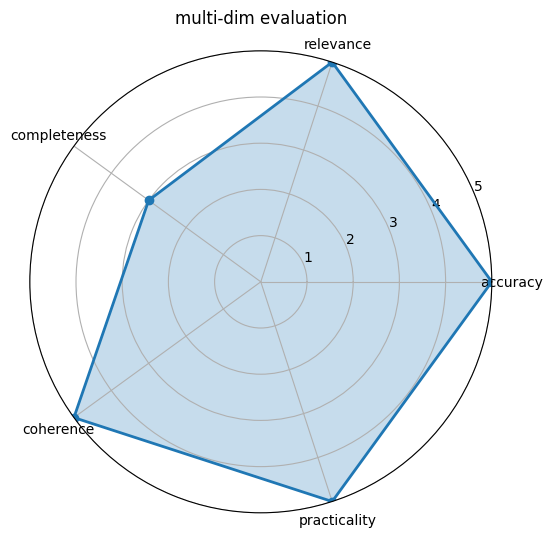

In [135]:
plot_radar(scores)

In [131]:
def plot_radar(scores_dict, title='multi-dim evaluation'):
    categories = list(scores_dict.keys())
    values = list(scores_dict.values())
    values += values[:1]
    
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, values, alpha=0.25)
    ax.plot(angles, values, 'o-', linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 5)
    ax.set_title(title, pad=20)
    plt.show()

In [ ]:
# 1. 위치 편향 : 앞에있는거에 후하게
# 2. 길이 편향 : 긴 답변에 높은 점수를 주는 경향
# 3. 자기 강화 편향 : LLM이 자신과 유사한 스타일의 문장에 후하게
    
# gpt4o-mini :
# opus : 
# gemini-flash

In [ ]:
# 나는 학교에 갑니다, 오늘은 날씨가 좋네요. : 

In [ ]:
# ensemble : retriever
# vector
# bm25
# ensembleretriever(ret1, ret2, weight1, weight2)

In [ ]:
# 다수결 : (a, b) (b,a) a
# 평균 : (1, 3, 2, 2,4) -> np.mean
# 절삭평균 
# 가중평균 (gpt-4o-mini, 최신모델)

In [137]:
def detect_length_bias(question, short_answer, long_answer):
    short_result = pointwise_judge(question, short_answer)
    long_result = pointwise_judge(question, long_answer)
    
    short_score = short_result.get('score')
    long_score = long_result.get('score')
    
    bias = long_score - short_score
    
    return {
        "short_score" : short_score,
        "long_score" : long_score,
        "bias" : bias,
        "short_len" : len(short_answer),
        "long_len" : len(long_answer),
        "has_bias" : bias>0
    }

In [138]:
question = "파이썬 GIL이란?"
short = "GIL은 한 번에 하나의 스레드만 파이썬 바이트코드를 실행하도록 제한하는 뮤텍스입니다."
long = "GIL(Global Interpreter Lock)은 CPython 인터프리터에서 사용되는 메커니즘입니다. GIL은 한 번에 하나의 스레드만 파이썬 바이트코드를 실행하도록 제한하는 뮤텍스(mutual exclusion lock)입니다. 이는 메모리 관리의 thread-safety를 위해 도입되었으나, 멀티스레드 프로그램의 병렬 실행을 제한하는 단점이 있습니다. 이를 우회하기 위해 multiprocessing 모듈을 사용하거나, I/O 바운드 작업에서는 asyncio를 활용할 수 있습니다."


In [139]:
result = detect_length_bias(question, short, long)

In [140]:
result

{'short_score': 4,
 'long_score': 5,
 'bias': 1,
 'short_len': 48,
 'long_len': 275,
 'has_bias': True}

In [144]:
[1,2,3,4,5][1:-1]

[2, 3, 4]

In [156]:
def ensemble_judge(question, answer, judge_fns, weight=None):
    scores= []
    for name, fn in judge_fns:
        result = fn(question, answer)
        score = result.get('score')
        scores.append(score)
        print(f"{name} : {score}")
        
    
    mean_score = np.mean(scores)
    median_score = np.median(scores)
    
    # 절삭평균 : 최대값, 최소값을 제외한 나머지의 평균
    if len(scores) >= 3:
        trimmed_mean = np.mean(sorted(scores)[1:-1])
    else:
        trimmed_mean = mean_score
    
    print(scores)
    # 가중평균
    if weight:
#         weighted_mean = np.mean([scores[idx]*weight[idx] for idx in range(len(scores))]) 
        weighted_mean = np.average(scores, weights=weight)  # 키워드 인수로 전달해야 함
    else:
        weighted_mean = mean_score
    
    return {
        'mean_score' : mean_score,
        'median_score' : median_score,
        'trimmed_mean' : trimmed_mean,
        'weighted_mean' : weighted_mean
    }

In [157]:
judge_fns = [
    ("pointwise", pointwise_judge),
    ("CoT", cot_judge),
    ("Few-shot", fewshot_judge)
]

question = "API 게이트웨이란?"
answer = "API 게이트웨이는 클라이언트와 백엔드 서비스 사이의 중간 계층으로, 인증, 라우팅, 속도 제한 등을 처리합니다."


result = ensemble_judge(question, answer, judge_fns, weight =  [1,2,3])
result

pointwise : 4
CoT : 4
Few-shot : 4
[4, 4, 4]


{'mean_score': np.float64(4.0),
 'median_score': np.float64(4.0),
 'trimmed_mean': np.float64(4.0),
 'weighted_mean': np.float64(4.0)}

In [ ]:
# 재현성 : 같은 입력으로 여러번 평가했을때 같은 결과 나오는지?
#     - 표준편차, 평균의 차이, 변동계수 (std/mean) < 0.1 

# 분별력 : 좋은 답변/나쁜 답변 -> 좋은 답변, 나쁜 답변 차이 > 1.5
    
# 정성평가 : human agreement
#     -> human answer - llm answer 상관관계 ()

In [158]:
def test_reproducibility(question, answer, n_trials=5):
    scores = []
    for i in range(n_trials):
        result = pointwise_judge(question, answer)
        score = result.get('score')
        scores.append(score)
    # [3, 4, 4, 4, 5]
    
    mean = np.mean(scores)
    std = np.std(scores)
    cv = std / mean if mean > 0 else float('inf')
    
    return {'scores' : scores, 'mean' : mean, 'std': std, 'cv':cv}

In [159]:
question = "REST API란?"
answer = "REST는 HTTP 프로토콜을 사용하여 리소스를 CRUD 방식으로 관리하는 아키텍처 스타일입니다."
test_reproducibility(question, answer, n_trials=5)

{'scores': [4, 4, 4, 4, 4],
 'mean': np.float64(4.0),
 'std': np.float64(0.0),
 'cv': np.float64(0.0)}

In [160]:
def test_discriminability(question, good_answer, bad_answer, n_trials=3):
    good_scores = []
    bad_scores = []
    
    for _ in range(n_trials):
        good_r = pointwise_judge(question, good_answer)
        bad_r = pointwise_judge(question, bad_answer)
        good_scores.append(good_r.get('score'))
        bad_scores.append(bad_r.get('score'))
        
    gap = np.mean(good_scores) - np.mean(bad_scores)
    
    return {
        'good_mean' : np.mean(good_scores),
        'bad_mean' : np.mean(bad_scores),
        'gap' : gap,
        'discriminable' : gap > 1.5
    }

In [161]:
test_discriminability(
    "데이터베이스 인덱스란?",
    "데이터베이스 인덱스는 테이블 검색 속도를 높이기 위한 자료구조입니다. B-Tree, Hash 등의 구조를 사용하며, SELECT 쿼리 성능을 크게 향상시킵니다.",
    "데이터베이스에 있는 것입니다."
)

{'good_mean': np.float64(4.0),
 'bad_mean': np.float64(1.0),
 'gap': np.float64(3.0),
 'discriminable': np.True_}

In [ ]:
# criteria evaluation

In [ ]:
# 관찰가능 : 예시가 포함되어 있는지
# 독립적 : 다른 기준과 겹치지 않는지
# 측정 가능 : 1~5 객관적으로 측정이 가능한지
# 평가 목적에 부합

In [168]:
class EvaluationCriterion:
    def __init__(self, name, description, scale=(1,5)):
        self.name = name
        self.description = description
        self.scale = scale
        
    def __repr__(self):
        return f"Criterion({self.name}: {self.description}, {self.scale[0]} - {self.scale[1]})"
        

In [169]:
STANDARD_CRITERIA = [
    EvaluationCriterion("accuracy",     "사실적으로 정확한 정보만 포함하는가"),
    EvaluationCriterion("relevance",    "질문의 의도와 범위에 적합한 답변인가"),
    EvaluationCriterion("completeness", "핵심 포인트를 빠짐없이 다루는가"),
    EvaluationCriterion("coherence",    "논리적 흐름과 구조가 일관적인가"),
]

In [171]:
print(EvaluationCriterion("coherence",    "논리적 흐름과 구조가 일관적인가"))

Criterion(coherence: 논리적 흐름과 구조가 일관적인가, 1 - 5)


In [172]:
def criteria_evaluate(question, answer, criterion):
    prompt = f"""당신은 전문 평가자입니다.
    아래 기준에 따라 답변을 {criterion.scale[0]}-{criterion.scale[1]} 스케일로 평가하세요.
    
    질문 : {question}
    답변 : {answer}
    
    평가 기준 [{criterion.name}] : {criterion.description}
    
    JSON으로 답하세요:
    {{"score" : {criterion.scale[0]}-{criterion.scale[1]}}}"""
    
    result = llm.invoke(prompt).content
    
    cleaned = result.strip()
    
    if cleaned.startswith("```"):
        cleaned = cleaned.split("```")[1].replace("json", "")
    
    return json.loads(cleaned)
    

In [173]:
question = "도커(Docker)의 장점을 설명해주세요"
answer = "도커는 컨테이너 기술로 애플리케이션을 격리된 환경에서 실행합니다. 가볍고 빠르며, 환경 일관성을 보장합니다."
for criterion in STANDARD_CRITERIA:
    result = criteria_evaluate(question, answer, criterion)
    print(f"{criterion.name} : {result.get('score')}")

accuracy : 4
relevance : 4
completeness : 3
coherence : 4
